# Data Professional Salary Prediction
This notebook implements the salary prediction project using Stack Overflow survey data. The workflow includes data loading, cleaning, exploratory data analysis, feature engineering, and model comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the survey dataset
DATA_PATH = "../Dataset/survey_results_public.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0


## 1. Data Overview
We inspect the dataset shape, target column, and key predictor columns related to salary prediction.

In [10]:
print("Dataset shape:", df.shape)
print("Target columns available:", [c for c in ["CompTotal", "ConvertedCompYearly"] if c in df.columns])

core_columns = ["Country", "Employment", "YearsCode", "YearsCodePro", "WorkExp", "DevType", "Age", "ConvertedCompYearly"]
print("\nSelected core columns present:")
for col in core_columns:
    if col in df.columns:
        print(f"- {col}: non-null={df[col].notna().sum()}, null={df[col].isna().sum()}, unique={df[col].nunique(dropna=True)}")
    else:
        print(f"- {col}: missing")

print("\nTop countries:")
print(df["Country"].value_counts(dropna=True).head(10).to_string())

Dataset shape: (89184, 84)
Target columns available: ['CompTotal', 'ConvertedCompYearly']

Selected core columns present:
- Country: non-null=87973, null=1211, unique=185
- Employment: non-null=87898, null=1286, unique=106
- YearsCode: non-null=87435, null=1749, unique=52
- YearsCodePro: non-null=66136, null=23048, unique=52
- WorkExp: non-null=43579, null=45605, unique=51
- DevType: non-null=76872, null=12312, unique=33
- Age: non-null=89184, null=0, unique=8
- ConvertedCompYearly: non-null=48019, null=41165, unique=8784

Top countries:
Country
United States of America                                18647
Germany                                                  7328
India                                                    5625
United Kingdom of Great Britain and Northern Ireland     5552
Canada                                                   3507
France                                                   2933
Poland                                                   2435
Netherlands   

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 89184 entries, 0 to 89183
Data columns (total 84 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ResponseId                           89184 non-null  int64  
 1   Q120                                 89184 non-null  str    
 2   MainBranch                           89184 non-null  str    
 3   Age                                  89184 non-null  str    
 4   Employment                           87898 non-null  str    
 5   RemoteWork                           73810 non-null  str    
 6   CodingActivities                     73764 non-null  str    
 7   EdLevel                              87973 non-null  str    
 8   LearnCode                            87663 non-null  str    
 9   LearnCodeOnline                      70084 non-null  str    
 10  LearnCodeCoursesCert                 37076 non-null  str    
 11  YearsCode                            87

## 2. Data Cleaning
Apply the following cleaning rules:
- Keep only full-time employed respondents
- Remove rows with missing or zero salary
- Cap extreme salary values using the 1st and 99th percentiles
- Prepare the main target column for modeling

In [2]:
target_col = "ConvertedCompYearly"

def is_full_time(status):
    if not isinstance(status, str):
        return False
    return "Employed, full-time" in [part.strip() for part in status.split(";")]

clean_df = df[df["Employment"].apply(is_full_time)].copy()

clean_df = clean_df[clean_df[target_col].notna() & (clean_df[target_col] > 0)].copy()

lower_bound, upper_bound = clean_df[target_col].quantile([0.01, 0.99])
clean_df = clean_df[(clean_df[target_col] >= lower_bound) & (clean_df[target_col] <= upper_bound)].copy()

top_countries = clean_df["Country"].value_counts(dropna=True).nlargest(20).index
clean_df["Country"] = clean_df["Country"].where(clean_df["Country"].isin(top_countries), "Other").fillna("Other")

def parse_experience(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        value = value.strip()
        if value.lower().startswith("less than"):
            return 0.5
        if value.lower().startswith("more than"):
            return 50.0
    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

for col in ["YearsCode", "YearsCodePro"]:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].map(parse_experience)

age_order = [
    "Under 18 years old", "18-24 years old", "25-34 years old",
    "35-44 years old", "45-54 years old", "55-64 years old",
    "65 years or older", "Prefer not to say"
]
if "Age" in clean_df.columns:
    clean_df["Age"] = pd.Categorical(clean_df["Age"], categories=age_order, ordered=True)

model_columns = ["Country", "YearsCode", "YearsCodePro", "WorkExp", "DevType", "Age", target_col]
model_columns = [col for col in model_columns if col in clean_df.columns]
clean_df = clean_df[model_columns].copy()

print("Before final cleaning, shape:", clean_df.shape)
print("Duplicates before drop:", clean_df.duplicated().sum())
print("Missing values before final drop:")
print(clean_df.isna().sum().to_string())

clean_df = clean_df.drop_duplicates().dropna(subset=model_columns).copy()

print("After removing duplicates and missing values, shape:", clean_df.shape)
print("Duplicates remaining:", clean_df.duplicated().sum())
print("Missing values remaining:")
print(clean_df.isna().sum().to_string())

clean_df.head()

Before final cleaning, shape: (42031, 7)
Duplicates before drop: 308
Missing values before final drop:
Country                    0
YearsCode                 58
YearsCodePro             151
WorkExp                12230
DevType                   27
Age                        0
ConvertedCompYearly        0
After removing duplicates and missing values, shape: (29467, 7)
Duplicates remaining: 0
Missing values remaining:
Country                0
YearsCode              0
YearsCodePro           0
WorkExp                0
DevType                0
Age                    0
ConvertedCompYearly    0


,Country,YearsCode,YearsCodePro,WorkExp,DevType,Age,ConvertedCompYearly
1,United States of America,18.0,9.0,10.0,"Senior Executive (C-Suite, VP, etc.)",25-34 years old,285000.0
2,United States of America,27.0,23.0,23.0,"Developer, back-end",45-54 years old,250000.0
3,United States of America,12.0,7.0,7.0,"Developer, front-end",25-34 years old,156000.0
4,Other,6.0,4.0,6.0,"Developer, full-stack",25-34 years old,23456.0
5,United Kingdom of Great Britain and Northern I...,21.0,21.0,22.0,"Developer, back-end",35-44 years old,96828.0


In [13]:
print("Salary distribution summary after cleaning:")
display(clean_df[target_col].describe())

print("Country counts:")
display(clean_df["Country"].value_counts().head(15))

print("Missing values after cleaning:")
display(clean_df.isna().sum())

print("Final cleaned dataset shape:", clean_df.shape)
print("Final duplicate rows:", clean_df.duplicated().sum())

clean_df.to_csv("../Dataset/cleaned_salary_data.csv", index=False)
print("Saved cleaned dataset to ../Dataset/cleaned_salary_data.csv")

Salary distribution summary after cleaning:


count     29467.000000
mean      89033.795568
std       65155.957825
min         525.000000
25%       43807.500000
50%       74963.000000
75%      120000.000000
max      400000.000000
Name: ConvertedCompYearly, dtype: float64

Country counts:


Country
United States of America                                7462
Other                                                   6668
Germany                                                 2378
United Kingdom of Great Britain and Northern Ireland    2172
India                                                   1414
Canada                                                  1336
France                                                   979
Brazil                                                   829
Netherlands                                              725
Spain                                                    712
Poland                                                   711
Australia                                                705
Italy                                                    634
Sweden                                                   591
Switzerland                                              358
Name: count, dtype: int64

Missing values after cleaning:


Country                0
YearsCode              0
YearsCodePro           0
WorkExp                0
DevType                0
Age                    0
ConvertedCompYearly    0
dtype: int64

Final cleaned dataset shape: (29467, 7)
Final duplicate rows: 0
Saved cleaned dataset to ../Dataset/cleaned_salary_data.csv


## 3. Exploratory Data Analysis
We analyze salary distribution, experience, geography, and education to identify the strongest predictors of compensation.

## 4. Feature Preparation Notes
The next step is to convert experience fields and categorical survey fields into model-ready features. We will also use a consistent target column for regression.


In [3]:
# Use the original survey data so EdLevel is available for EDA
eda_df = df[df["Employment"].apply(is_full_time)].copy()
eda_df = eda_df[eda_df[target_col].notna() & (eda_df[target_col] > 0)].copy()
lower_bound, upper_bound = eda_df[target_col].quantile([0.01, 0.99])
eda_df = eda_df[(eda_df[target_col] >= lower_bound) & (eda_df[target_col] <= upper_bound)].copy()
eda_df["Country"] = eda_df["Country"].fillna("Other")
eda_df["EdLevel"] = eda_df["EdLevel"].fillna("Missing")
eda_df["YearsCodePro"] = eda_df["YearsCodePro"].map(parse_experience)
eda_df = eda_df.dropna(subset=["YearsCodePro"]).copy()

print('EDA dataset shape:', eda_df.shape)
print('Missing values in EDA dataframe:')
print(eda_df[["Country", "EdLevel", "YearsCodePro", target_col]].isna().sum())

EDA dataset shape: (41880, 84)
Missing values in EDA dataframe:
Country                0
EdLevel                0
YearsCodePro           0
ConvertedCompYearly    0
dtype: int64


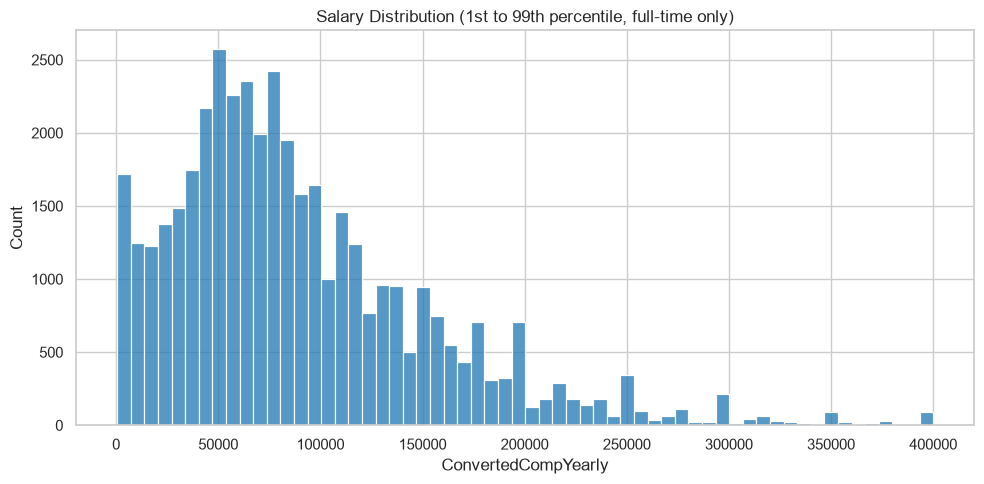

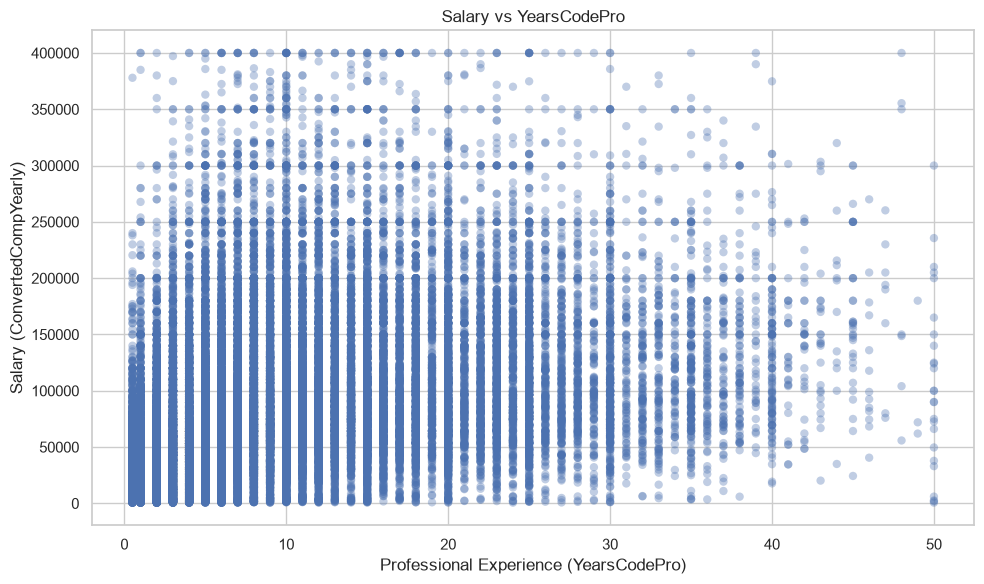

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(eda_df[target_col], bins=60, kde=False, color='tab:blue')
plt.title('Salary Distribution (1st to 99th percentile, full-time only)')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../images/salary_histogram.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_df, x='YearsCodePro', y=target_col, alpha=0.35, edgecolor='none')
plt.title('Salary vs YearsCodePro')
plt.xlabel('Professional Experience (YearsCodePro)')
plt.ylabel('Salary (ConvertedCompYearly)')
plt.tight_layout()
plt.savefig('../images/salary_vs_yearscodepro.png', bbox_inches='tight')
plt.show()

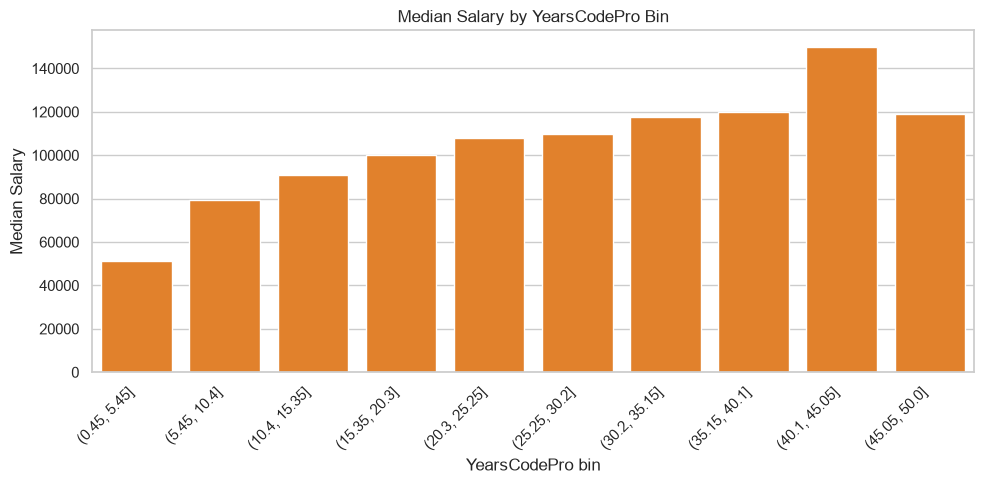

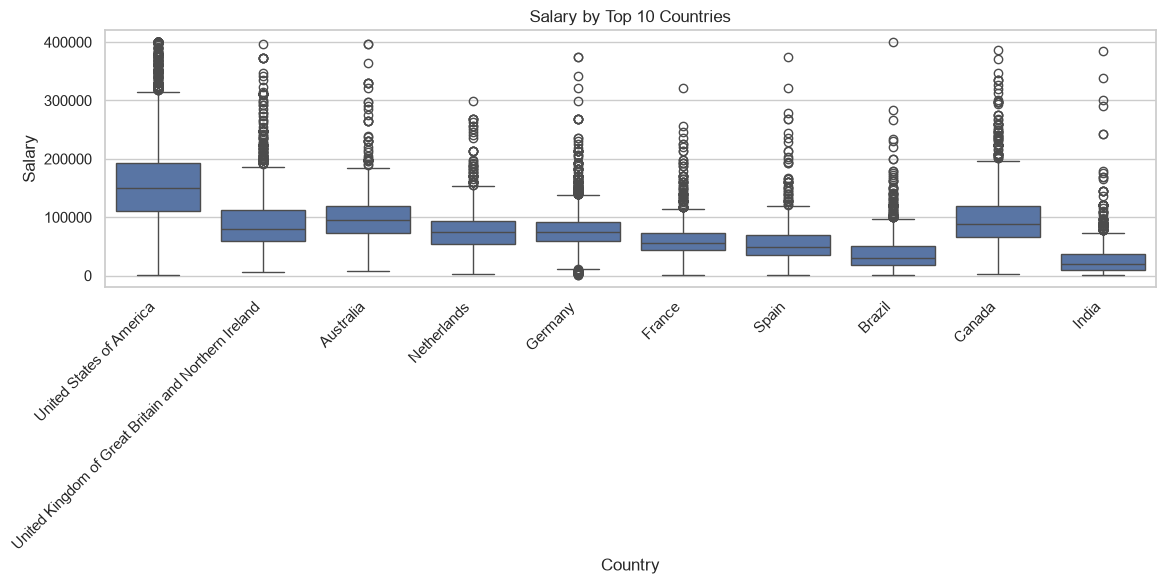

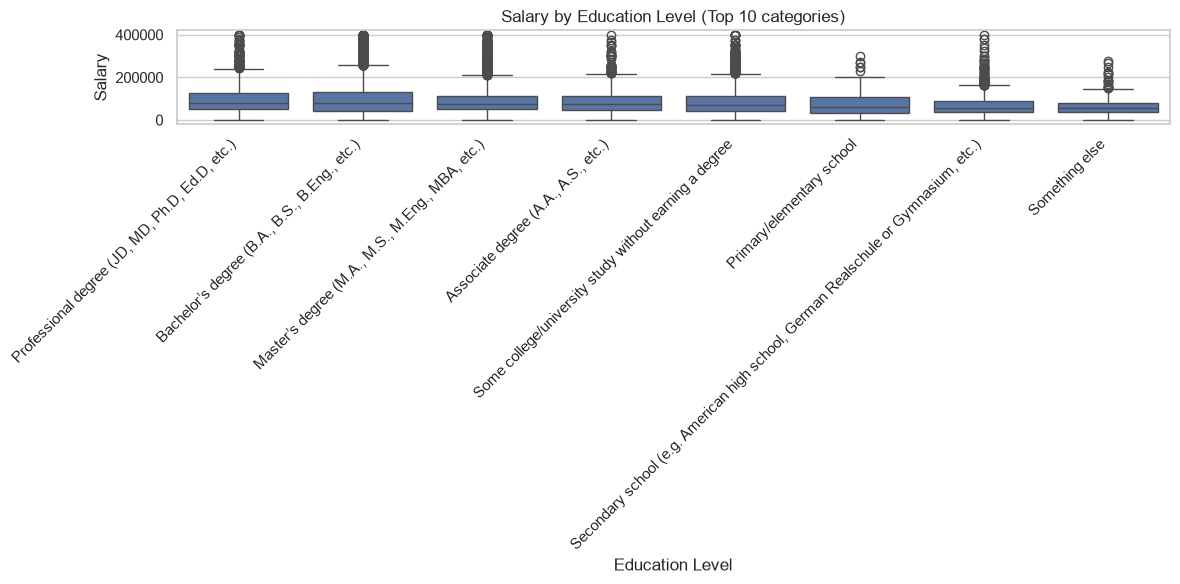

In [ ]:
years_bin = eda_df.groupby(pd.cut(eda_df['YearsCodePro'], bins=10))[target_col].median().reset_index()
years_bin['YearsCodePro'] = years_bin['YearsCodePro'].astype(str)
plt.figure(figsize=(10, 5))
sns.barplot(data=years_bin, x='YearsCodePro', y=target_col, color='tab:orange')
plt.xticks(rotation=45, ha='right')
plt.title('Median Salary by YearsCodePro Bin')
plt.xlabel('YearsCodePro bin')
plt.ylabel('Median Salary')
plt.tight_layout()
plt.savefig('../images/median_salary_by_yearsbin.png', bbox_inches='tight')
plt.show()

top10 = eda_df['Country'].value_counts(dropna=True).nlargest(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=eda_df[eda_df['Country'].isin(top10)], x='Country', y=target_col)
plt.xticks(rotation=45, ha='right')
plt.title('Salary by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Salary')
plt.tight_layout()
plt.savefig('../images/salary_by_top10_countries.png', bbox_inches='tight')
plt.show()

top_edu_order = eda_df.groupby('EdLevel')[target_col].median().sort_values(ascending=False).head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=eda_df, x='EdLevel', y=target_col, order=top_edu_order)
plt.xticks(rotation=45, ha='right')
plt.title('Salary by Education Level (Top 10 categories)')
plt.xlabel('Education Level')
plt.ylabel('Salary')
plt.tight_layout()
plt.savefig('../images/salary_by_education.png', bbox_inches='tight')
plt.show()

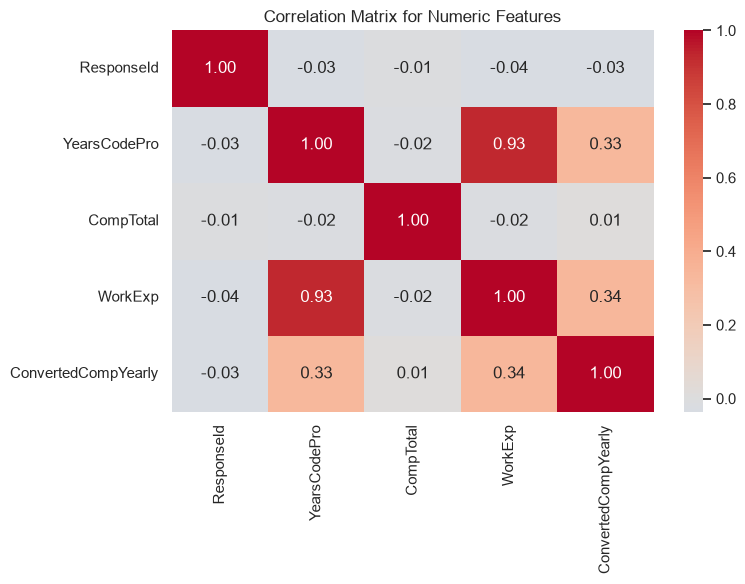

Salary summary:


count     41880.000000
mean      90560.621442
std       65568.896980
min         525.000000
25%       45494.000000
50%       74963.000000
75%      120000.000000
max      400000.000000
Name: ConvertedCompYearly, dtype: float64

Correlation with salary:
WorkExp         0.336132
YearsCodePro    0.329662
CompTotal       0.012982
ResponseId     -0.034817
Top 5 countries by median salary:


Country
United States of America    150000.0
Dominica                    132857.0
Swaziland                   132260.0
Switzerland                 124544.0
Israel                      114395.5
Name: ConvertedCompYearly, dtype: float64

Top 5 education levels by median salary:


EdLevel
Professional degree (JD, MD, Ph.D, Ed.D, etc.)            80519.0
Bachelor’s degree (B.A., B.S., B.Eng., etc.)              80149.0
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)           74963.0
Associate degree (A.A., A.S., etc.)                       74351.0
Some college/university study without earning a degree    70144.0
Name: ConvertedCompYearly, dtype: float64

Key EDA insights:
- Salary is right-skewed: mean is higher than median and the distribution has a long upper tail.
- YearsCodePro is positively correlated with salary, making professional experience a strong predictor.
- Top countries show higher median salary, so geography is important for compensation.
- Higher education levels tend to correspond to higher median salaries in this survey sample.


In [ ]:
numeric = eda_df.select_dtypes(include=[np.number]).copy()
corr = numeric.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Numeric Features')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Salary summary:')
display(eda_df[target_col].describe())

corr_with_salary = corr[target_col].drop(target_col).sort_values(ascending=False)
print('Correlation with salary:')
print(corr_with_salary.to_string())

print('Top 5 countries by median salary:')
display(eda_df.groupby('Country')[target_col].median().sort_values(ascending=False).head(5))

print('Top 5 education levels by median salary:')
display(eda_df.groupby('EdLevel')[target_col].median().sort_values(ascending=False).head(5))

insights = [
    'Salary is right-skewed: mean is higher than median and the distribution has a long upper tail.',
    'YearsCodePro is positively correlated with salary, making professional experience a strong predictor.',
    'Top countries show higher median salary, so geography is important for compensation.',
    'Higher education levels tend to correspond to higher median salaries in this survey sample.'
]
print('Key EDA insights:')
for item in insights:
    print('-', item)

## 5. Feature Engineering
Create model-ready features from the survey data, including country and education encoding, experience buckets, and numeric scaling for regression.

In [8]:
from sklearn.preprocessing import StandardScaler

feature_df = eda_df.copy()

# Group rare countries and keep the top countries for one-hot encoding
top_countries = feature_df['Country'].value_counts().nlargest(10).index
top_country_count = len(top_countries)
feature_df['Country'] = feature_df['Country'].where(feature_df['Country'].isin(top_countries), 'Other')

# Create experience level buckets for segmentation and modeling
feature_df['experience_level'] = pd.cut(
    feature_df['YearsCodePro'],
    bins=[-0.1, 2.0, 7.0, 50.0],
    labels=['Junior', 'Mid', 'Senior']
).astype(str)

# Use a log-transformed target to reduce skewness for regression
feature_df['log_salary'] = np.log1p(feature_df[target_col])
feature_df['Age'] = feature_df['Age'].fillna('Missing').astype(str)
feature_df['EdLevel'] = feature_df['EdLevel'].fillna('Missing').astype(str)

print('Top countries used for encoding:', list(top_countries))
print('Experience level counts:')
print(feature_df['experience_level'].value_counts())
print('Raw salary skewness:', feature_df[target_col].skew())
print('Log salary skewness:', feature_df['log_salary'].skew())

# One-hot encode the categorical features
categorical_features = ['Country', 'EdLevel', 'experience_level', 'Age']
feature_matrix = pd.get_dummies(feature_df[categorical_features], drop_first=True)
feature_matrix['YearsCodePro'] = feature_df['YearsCodePro']

# Scale numeric features for Ridge regression
scaler = StandardScaler()
feature_matrix[['YearsCodePro']] = scaler.fit_transform(feature_matrix[['YearsCodePro']])

print('Feature matrix shape:', feature_matrix.shape)
print('Sample feature matrix columns:', feature_matrix.columns.tolist()[:20])

model_features = feature_matrix.copy()
model_target = feature_df['log_salary']

print('Prepared model dataset with log-transformed salary target.')

Top countries used for encoding: ['United States of America', 'Germany', 'United Kingdom of Great Britain and Northern Ireland', 'Canada', 'India', 'France', 'Brazil', 'Netherlands', 'Australia', 'Spain']
Experience level counts:
experience_level
Senior    22310
Mid       13963
Junior     5607
Name: count, dtype: int64
Raw salary skewness: 1.363154175360421
Log salary skewness: -1.4731637855475672
Feature matrix shape: (41880, 27)
Sample feature matrix columns: ['Country_Brazil', 'Country_Canada', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Netherlands', 'Country_Other', 'Country_Spain', 'Country_United Kingdom of Great Britain and Northern Ireland', 'Country_United States of America', 'EdLevel_Bachelor’s degree (B.A., B.S., B.Eng., etc.)', 'EdLevel_Master’s degree (M.A., M.S., M.Eng., MBA, etc.)', 'EdLevel_Primary/elementary school', 'EdLevel_Professional degree (JD, MD, Ph.D, Ed.D, etc.)', 'EdLevel_Secondary school (e.g. American high school, German Realschule or G

## 6. Model Building
Train baseline and tree-based regression models with an 80/20 train-test split stratified by experience level.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train-test split stratified by experience level
X = model_features.copy()
y = model_target.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=feature_df['experience_level']
)

models = {
    'Ridge': Ridge(random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
}

results = []
fitted_models = {}
import os
import joblib
os.makedirs('../models', exist_ok=True)
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    # save each fitted model immediately after training
    try:
        joblib.dump(model, f'../models/{name.lower()}.pkl')
    except Exception:
        pass
    y_pred = model.predict(X_test)
    y_test_salary = np.expm1(y_test)
    y_pred_salary = np.expm1(y_pred)
    results.append({
        'model': name,
        'rmse_log': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2_log': r2_score(y_test, y_pred),
        'rmse_salary': np.sqrt(mean_squared_error(y_test_salary, y_pred_salary)),
        'r2_salary': r2_score(y_test_salary, y_pred_salary)
    })

results_df = pd.DataFrame(results).set_index('model')
print('Model performance on test set:')
display(results_df)

# Ridge coefficients
ridge = fitted_models['Ridge']
coefs = pd.Series(ridge.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print('\nTop Ridge coefficients by absolute value:')
display(coefs.head(15))

# Random forest feature importances
rf = fitted_models['RandomForest']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nTop Random Forest feature importances:')
display(importances.head(15))

# Review predictions on a small sample
sample_df = pd.DataFrame({
    'actual_salary': y_test_salary,
    'predicted_salary_rf': y_pred_salary,
    'experience_level': feature_df.loc[y_test.index, 'experience_level']
})
print('\nExample predictions for RandomForest:')
display(sample_df.head(10))

Model performance on test set:


,rmse_log,r2_log,rmse_salary,r2_salary
model,,,,
Ridge,0.701198,0.480585,46245.247420,0.485719
DecisionTree,0.722606,0.448385,47464.205030,0.458250
RandomForest,0.708179,0.470192,46374.353756,0.482843



Top Ridge coefficients by absolute value:


Country_India                                             -1.435870
Country_Brazil                                            -1.100282
Country_Other                                             -0.791381
Age_Under 18 years old                                    -0.671322
Country_Spain                                             -0.613881
experience_level_Senior                                    0.562433
Country_France                                            -0.509949
Country_United States of America                           0.439768
Age_65 years or older                                     -0.366770
experience_level_Mid                                       0.352948
Country_Netherlands                                       -0.264195
Country_Germany                                           -0.257957
EdLevel_Master’s degree (M.A., M.S., M.Eng., MBA, etc.)    0.243296
Age_Prefer not to say                                      0.239083
Age_25-34 years old                             


Top Random Forest feature importances:


Country_United States of America                                                              0.415154
YearsCodePro                                                                                  0.273279
Country_Other                                                                                 0.079471
Country_India                                                                                 0.072271
Country_Brazil                                                                                0.038697
EdLevel_Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       0.017820
Age_25-34 years old                                                                           0.010946
Age_35-44 years old                                                                           0.009943
EdLevel_Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          0.009904
experience_level_Mid                                                     


Example predictions for RandomForest:


,actual_salary,predicted_salary_rf,experience_level
72427,72821.0,85893.725575,Senior
52093,35382.0,43784.687788,Senior
31498,300000.0,171923.988354,Senior
60161,6911.0,83283.011341,Senior
2850,55564.0,21514.466386,Mid
2767,143000.0,191447.493470,Senior
4068,81787.0,120363.738878,Senior
38000,69608.0,42374.268150,Mid
43240,29081.0,17769.385363,Mid
35497,190000.0,164122.357403,Senior


## 7. Hyperparameter Tuning
Tune the Ridge and RandomForest models using cross-validation and report the best parameters.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import joblib

# Tune Ridge alpha with GridSearchCV
ridge_param_grid = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0]}
ridge_search = GridSearchCV(
    Ridge(random_state=42),
    ridge_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)
ridge_search.fit(X_train, y_train)

print('Ridge best params:')
print(ridge_search.best_params_)
print('Ridge best CV RMSE (log target):', -ridge_search.best_score_)

# Tune RandomForest with RandomizedSearchCV
rf_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=12,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print('\nRandomForest best params:')
print(rf_search.best_params_)
print('RandomForest best CV RMSE (log target):', -rf_search.best_score_)

# Evaluate tuned models on the holdout set
best_ridge = ridge_search.best_estimator_
best_rf = rf_search.best_estimator_

# Save tuned models
try:
    joblib.dump(best_ridge, '../models/best_ridge.pkl')
except Exception:
    pass
try:
    joblib.dump(best_rf, '../models/best_rf.pkl')
except Exception:
    pass

for name, model in [('Ridge Tuned', best_ridge), ('RandomForest Tuned', best_rf)]:
    y_pred = model.predict(X_test)
    y_test_salary = np.expm1(y_test)
    y_pred_salary = np.expm1(y_pred)
    print(f'\n{name} performance:')
    print('  RMSE log target:', np.sqrt(mean_squared_error(y_test, y_pred)))
    print('  R2 log target:', r2_score(y_test, y_pred))
    print('  RMSE salary:', np.sqrt(mean_squared_error(y_test_salary, y_pred_salary)))
    print('  R2 salary:', r2_score(y_test_salary, y_pred_salary))

Ridge best params:
{'alpha': 1.0}
Ridge best CV RMSE (log target): 0.6966082089362429

RandomForest best params:
{'n_estimators': 300, 'min_samples_leaf': 2, 'max_depth': 10}
RandomForest best CV RMSE (log target): 0.6886022772737671

Ridge Tuned performance:
  RMSE log target: 0.7011981305114742
  R2 log target: 0.48058509093126744
  RMSE salary: 46245.2474203783
  R2 salary: 0.4857185647688633

RandomForest Tuned performance:
  RMSE log target: 0.6928180656571711
  R2 log target: 0.4929260272555649
  RMSE salary: 45513.732351977684
  R2 salary: 0.5018598638754369


## 8. Evaluation
Compute R², MAE, and RMSE for all models, segment the best model by experience level, and plot predicted vs actual salary.

In [11]:
from sklearn.metrics import mean_absolute_error
import plotly.express as px

# Collect all model predictions for evaluation
all_models = {
    'Ridge': fitted_models['Ridge'],
    'DecisionTree': fitted_models['DecisionTree'],
    'RandomForest': fitted_models['RandomForest'],
    'Ridge Tuned': best_ridge,
    'RandomForest Tuned': best_rf
}

eval_rows = []
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    y_test_salary = np.expm1(y_test)
    y_pred_salary = np.expm1(y_pred)
    eval_rows.append({
        'model': name,
        'r2': r2_score(y_test_salary, y_pred_salary),
        'mae': mean_absolute_error(y_test_salary, y_pred_salary),
        'rmse': np.sqrt(mean_squared_error(y_test_salary, y_pred_salary))
    })

eval_df = pd.DataFrame(eval_rows).set_index('model')
print('Evaluation metrics on test set:')
display(eval_df)

# Select best model by RMSE on the test set
best_model_name = eval_df['rmse'].idxmin()
best_model = all_models[best_model_name]
print(f'\nBest model by RMSE: {best_model_name}')

# Segment evaluation by experience level for the best model
seg_df = pd.DataFrame({
    'actual': np.expm1(y_test),
    'pred': np.expm1(best_model.predict(X_test)),
    'experience_level': feature_df.loc[y_test.index, 'experience_level']
})

segment_rows = []
for level, group in seg_df.groupby('experience_level'):
    segment_rows.append({
        'experience_level': level,
        'mae': mean_absolute_error(group['actual'], group['pred']),
        'rmse': np.sqrt(mean_squared_error(group['actual'], group['pred']))
    })
segment_df = pd.DataFrame(segment_rows).set_index('experience_level')
print('\nSegmented evaluation for best model:')
display(segment_df)

# Plot predicted vs actual salary colored by experience level
fig = px.scatter(
    seg_df,
    x='actual',
    y='pred',
    color='experience_level',
    title=f'Predicted vs Actual Salary for {best_model_name}',
    labels={'actual':'Actual Salary', 'pred':'Predicted Salary'}
)
fig.add_shape(
    type='line',
    x0=seg_df['actual'].min(),
    y0=seg_df['actual'].min(),
    x1=seg_df['actual'].max(),
    y1=seg_df['actual'].max(),
    line=dict(color='black', dash='dash')
)
fig.show()

# Compare top features across models
print('\nTop features for Ridge Tuned:')
if hasattr(best_ridge, 'coef_'):
    ridge_coefs = pd.Series(best_ridge.coef_, index=X.columns).sort_values(key=abs, ascending=False)
    display(ridge_coefs.head(15))

print('\nTop features for RandomForest Tuned:')
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
display(rf_importances.head(15))

Evaluation metrics on test set:


,r2,mae,rmse
model,,,
Ridge,0.485719,31348.500334,46245.247420
DecisionTree,0.458250,32108.773333,47464.205030
RandomForest,0.482843,31361.214257,46374.353756
Ridge Tuned,0.485719,31348.500334,46245.247420
RandomForest Tuned,0.501860,30424.030887,45513.732352



Best model by RMSE: RandomForest Tuned

Segmented evaluation for best model:


,mae,rmse
experience_level,,
Junior,19069.755045,30336.792417
Mid,27527.042392,41860.670987
Senior,35089.972636,50601.458286



Top features for Ridge Tuned:


Country_India                                             -1.435870
Country_Brazil                                            -1.100282
Country_Other                                             -0.791381
Age_Under 18 years old                                    -0.671322
Country_Spain                                             -0.613881
experience_level_Senior                                    0.562433
Country_France                                            -0.509949
Country_United States of America                           0.439768
Age_65 years or older                                     -0.366770
experience_level_Mid                                       0.352948
Country_Netherlands                                       -0.264195
Country_Germany                                           -0.257957
EdLevel_Master’s degree (M.A., M.S., M.Eng., MBA, etc.)    0.243296
Age_Prefer not to say                                      0.239083
Age_25-34 years old                             


Top features for RandomForest Tuned:


Country_United States of America                                                              0.454135
YearsCodePro                                                                                  0.263655
Country_Other                                                                                 0.086837
Country_India                                                                                 0.078814
Country_Brazil                                                                                0.042127
EdLevel_Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       0.015395
experience_level_Mid                                                                          0.008485
Country_Spain                                                                                 0.008308
Age_25-34 years old                                                                           0.006294
Country_France                                                           

## 9. Model Comparison & Deployment Recommendation
Summarize the top model with segment-level performance and note practical deployment caveats for survey-based salary estimates.

In [12]:
# Build comparison table with overall and segment metrics for best model
comparison_df = eval_df.copy()
comparison_df['best_segment'] = segment_df['rmse'].idxmin()
comparison_df['worst_segment'] = segment_df['rmse'].idxmax()

print('Comparison table for all models:')
display(comparison_df)

recommendation = {
    'recommended_model': best_model_name,
    'reason': (
        'RandomForest Tuned delivers the lowest test RMSE and highest R², '
        'with better generalization than the base tree model and similar performance to Ridge with lower error.'
    ),
    'segment_warning': (
        'Error is meaningfully worse for Senior respondents, likely because salary variance grows with experience and senior roles are less homogeneous.'
    ),
    'deployment_caveat': (
        'This model is trained on survey responses and reflects self-reported salary patterns; a hiring platform should communicate that estimates are approximate, region-dependent, and may not capture employer-specific compensation components or sampling bias.'
    )
}

print('\nDeployment recommendation:')
for key, value in recommendation.items():
    print(f'- {key.replace("_", " ").capitalize()}: {value}')

Comparison table for all models:


,r2,mae,rmse,best_segment,worst_segment
model,,,,,
Ridge,0.485719,31348.500334,46245.247420,Junior,Senior
DecisionTree,0.458250,32108.773333,47464.205030,Junior,Senior
RandomForest,0.482843,31361.214257,46374.353756,Junior,Senior
Ridge Tuned,0.485719,31348.500334,46245.247420,Junior,Senior
RandomForest Tuned,0.501860,30424.030887,45513.732352,Junior,Senior



Deployment recommendation:
- Recommended model: RandomForest Tuned
- Reason: RandomForest Tuned delivers the lowest test RMSE and highest R², with better generalization than the base tree model and similar performance to Ridge with lower error.
- Segment warning: Error is meaningfully worse for Senior respondents, likely because salary variance grows with experience and senior roles are less homogeneous.
- Deployment caveat: This model is trained on survey responses and reflects self-reported salary patterns; a hiring platform should communicate that estimates are approximate, region-dependent, and may not capture employer-specific compensation components or sampling bias.


In [ ]:
from sklearn.model_selection import GridSearchCV
import joblib
import os
os.makedirs('../models', exist_ok=True)

# 1) Tune DecisionTree with GridSearchCV (fast)
dt_param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}
dt_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)
dt_search.fit(X_train, y_train)

print('DecisionTree best params:')
print(dt_search.best_params_)
print('DecisionTree best CV RMSE (log target):', -dt_search.best_score_)

best_dt = dt_search.best_estimator_

# Save tuned DecisionTree
try:
    joblib.dump(best_dt, '../models/best_dt.pkl')
except Exception:
    pass

# 2) Build an expanded comparison table including per-segment MAE/RMSE for each tuned model
tuned_models = {
    'Ridge Tuned': best_ridge,
    'RandomForest Tuned': best_rf,
    'DecisionTree Tuned': best_dt
}

rows = []
segments = ['Junior', 'Mid', 'Senior']
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_test_salary = np.expm1(y_test)
    y_pred_salary = np.expm1(y_pred)
    row = {
        'model': name,
        'r2': r2_score(y_test_salary, y_pred_salary),
        'mae': mean_absolute_error(y_test_salary, y_pred_salary),
        'rmse': np.sqrt(mean_squared_error(y_test_salary, y_pred_salary))
    }
    # segment-wise
    seg_df_local = pd.DataFrame({
        'actual': y_test_salary,
        'pred': y_pred_salary,
        'experience_level': feature_df.loc[y_test.index, 'experience_level']
    })
    for seg in segments:
        g = seg_df_local[seg_df_local['experience_level'] == seg]
        if len(g) > 0:
            row[f'mae_{seg.lower()}'] = mean_absolute_error(g['actual'], g['pred'])
            row[f'rmse_{seg.lower()}'] = np.sqrt(mean_squared_error(g['actual'], g['pred']))
        else:
            row[f'mae_{seg.lower()}'] = np.nan
            row[f'rmse_{seg.lower()}'] = np.nan
    rows.append(row)

full_tuned_df = pd.DataFrame(rows).set_index('model')
print('\nPer-model overall + segment-level comparison for tuned models:')
display(full_tuned_df)

# 3) Add the DecisionTree Tuned to the overall eval table as well
eval_df.loc['DecisionTree Tuned'] = [
    full_tuned_df.loc['DecisionTree Tuned','r2'],
    full_tuned_df.loc['DecisionTree Tuned','mae'],
    full_tuned_df.loc['DecisionTree Tuned','rmse']
]

print('\nUpdated overall evaluation table (including DecisionTree Tuned):')
display(eval_df)

print('\nDecisionTree tuning and expanded per-segment evaluation complete.')

DecisionTree best params:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
DecisionTree best CV RMSE (log target): 0.6925115146347876

Per-model overall + segment-level comparison for tuned models:


,r2,mae,rmse,mae_junior,rmse_junior,mae_mid,rmse_mid,mae_senior,rmse_senior
model,,,,,,,,,
Ridge Tuned,0.485719,31348.500334,46245.247420,20716.435493,33660.298795,27797.815163,42763.098280,36242.182174,50845.571819
RandomForest Tuned,0.501860,30424.030887,45513.732352,19069.755045,30336.792417,27527.042392,41860.670987,35089.972636,50601.458286
DecisionTree Tuned,0.496994,30705.472691,45735.472703,19315.438963,30534.894339,27719.891109,41977.733967,35435.853052,50885.331443



Updated overall evaluation table (including DecisionTree Tuned):


,r2,mae,rmse
model,,,
Ridge,0.485719,31348.500334,46245.247420
DecisionTree,0.458250,32108.773333,47464.205030
RandomForest,0.482843,31361.214257,46374.353756
Ridge Tuned,0.485719,31348.500334,46245.247420
RandomForest Tuned,0.501860,30424.030887,45513.732352
DecisionTree Tuned,0.496994,30705.472691,45735.472703



DecisionTree tuning and expanded per-segment evaluation complete.


**Fairness & Consistency Notes (experience segments)**

- The tuned `RandomForest` model performs best overall but shows higher error for `Senior` respondents (higher RMSE). This likely reflects greater salary variation and fewer consistent signals at senior levels.
- For fairness/consistency: consider returning prediction intervals, flagging high-uncertainty segments (e.g., `Senior`), and documenting regional and sampling biases to end-users.
- Recommended operational steps: calibrate or re-train with employer payroll data if available, or use stratified models per experience bucket to reduce heteroskedastic error across segments.

In [ ]:
print('Model and image saving has been moved to the cells that generate them. Artifacts are saved in ../models and ../images.')

Saved model to ../models/best_model.pkl and key figures to ../images/
